# Clean JSON Export Inspection

This notebook loads the latest `processed_export_*.json` from the minimal schema
and builds a quick catalog of the available tables and images grouped by section.

In [50]:
import pandas as pd
from pathlib import Path
from IPython.display import display, Image

# Import the export reader library
from scraper.export_reader import load_latest_export

# Load the latest export
reader = load_latest_export()

# Print summary
reader.print_summary()

# Get documents dataframe
df_documents = reader.get_documents_dataframe()
print(f"\nLoaded {len(df_documents)} documents")


Loading latest export: processed_export_1779286564.json
EXPORT SUMMARY
Total documents: 283
Export file: /home/jgrzyb/Documents/Python/ai4es-oa-paper-scrapper/notebooks/paper_pipeline_data/exports/processed_export_1779286564.json

Documents by source:
source
pmc      264
arxiv     19

Total tables: 2387
Total images: 1727

Document sections:
  Min sections: 0
  Max sections: 49
  Avg sections: 17.5


Loaded 283 documents


## Data Parsing

In [51]:
# Get all tables as a dataframe
df_tables = reader.get_all_tables_dataframe()
print(f"Total tables: {len(df_tables)}")
display(df_tables.head(20))

# Get all images as a dataframe
df_images = reader.get_all_images_dataframe()
print(f"\nTotal images: {len(df_images)}")
display(df_images.head(20))


Total tables: 2387


,paper_id,section,table_index,global_index,csv_path
0,0903.2017,References,0,0,tables/0903.2017/table_0.csv
1,0903.2017,Radius of the double occupancies,0,1,tables/0903.2017/table_1.csv
2,0903.2017,Expansion from the harmonic trap: Reduction of...,0,2,tables/0903.2017/table_2.csv
3,PMC6004667,Results,0,0,tables/PMC6004667/table_0.csv
4,PMC6004667,Results,1,1,tables/PMC6004667/table_1.csv
5,PMC6004667,Results,2,2,tables/PMC6004667/table_2.csv
6,PMC6004667,Results,3,3,tables/PMC6004667/table_3.csv
7,PMC6004667,Characteristics of included studies,0,4,tables/PMC6004667/table_4.csv
8,PMC6004667,Prevalence of spider mite sensitization,0,5,tables/PMC6004667/table_5.csv
9,PMC6004667,"Publication bias, sensitivity, and meta-regres...",0,6,tables/PMC6004667/table_6.csv



Total images: 1727


,paper_id,section,placeholder,caption,path
0,0903.2017,Expansion from the harmonic trap: Reduction of...,https://ar5iv.org/html/0903.2017/assets/x5.png,Figure 5: (Color online) Average double occupa...,https://ar5iv.org/html/0903.2017/assets/x5.png
1,0903.2017,Expansion from the harmonic trap: Reduction of...,https://ar5iv.org/html/0903.2017/assets/x6.png,Figure 6: (Color online) Average double occupa...,https://ar5iv.org/html/0903.2017/assets/x6.png
2,0903.2017,Expansion from the harmonic trap: Reduction of...,https://ar5iv.org/html/0903.2017/assets/x7.png,Figure 7: (Color online) Average double occupa...,https://ar5iv.org/html/0903.2017/assets/x7.png
3,0903.2017,Expansion from the harmonic trap: Reduction of...,https://ar5iv.org/html/0903.2017/assets/x8.png,Figure 8: (Color online) Average double occupa...,https://ar5iv.org/html/0903.2017/assets/x8.png
4,0903.2017,Expansion from the harmonic trap: Reduction of...,https://ar5iv.org/html/0903.2017/assets/x9.png,Figure 9: (Color online) Dependence of the ave...,https://ar5iv.org/html/0903.2017/assets/x9.png
5,0903.2017,Expansion from the harmonic trap: Reduction of...,https://ar5iv.org/html/0903.2017/assets/x10.png,Figure 10: (Color online) Radius R d subscript...,https://ar5iv.org/html/0903.2017/assets/x10.png
6,0903.2017,Expansion from the harmonic trap: Reduction of...,https://ar5iv.org/html/0903.2017/assets/x11.png,Figure 11: (Color online) Reduction of the ent...,https://ar5iv.org/html/0903.2017/assets/x11.png
7,0903.2017,Expansion from the harmonic trap: Reduction of...,https://ar5iv.org/html/0903.2017/assets/x13.png,Figure 12: (Color online) Average double occup...,https://ar5iv.org/html/0903.2017/assets/x13.png
8,PMC6004667,Results,PMC_FIG_0,Fig. 1 Flow chart of screening and inclusion o...,png/PMC6004667/13601_2018_209_Fig4_HTML.jpg
9,PMC6004667,Results,PMC_FIG_1,Fig. 2 Forest plot of prevalence estimates of ...,png/PMC6004667/13601_2018_209_Fig2_HTML.jpg


## Utilities for inspection

In [52]:
def show_table(index):
    """Display a specific table from the tables dataframe."""
    if index < 0 or index >= len(df_tables):
        print('Index out of range')
        return
    
    row = df_tables.iloc[index]
    print(f"Paper: {row['paper_id']}")
    print(f"Section: {row['section']}")
    print(f"Table Index: {row['table_index']} (Global: {row['global_index']})")
    print(f"CSV Path: {row['csv_path']}")
    print()
    
    try:
        df = reader.load_table_csv(row['csv_path'])
        display(df)
    except FileNotFoundError as e:
        print(f"Error: {e}")

def show_image(index):
    """Display a specific image from the images dataframe."""
    if index < 0 or index >= len(df_images):
        print('Index out of range')
        return
    
    row = df_images.iloc[index]
    print(f"Paper: {row['paper_id']}")
    print(f"Section: {row['section']}")
    print(f"Caption: {row['caption']}")
    print(f"Placeholder: {row['placeholder']}")
    print()
    
    try:
        path = row['path']
        
        # Check if it's a URL (handle malformed URLs too)
        if 'http' in path.lower():
            # Try to fix malformed URLs (https:/ -> https://)
            if path.startswith('https:/') and not path.startswith('https://'):
                path = path.replace('https:/', 'https://', 1)
            elif path.startswith('http:/') and not path.startswith('http://'):
                path = path.replace('http:/', 'http://', 1)
            
            print(f"Remote image: {path}")
            display(Image(url=path))
        else:
            # Local file path
            img_path = reader.get_file_path(path)
            if Path(img_path).exists():
                display(Image(filename=img_path))
            else:
                print(f"Image file not found: {img_path}")
    except Exception as e:
        print(f"Error displaying image: {e}")

def show_document(paper_id):
    """Display complete information about a document."""
    meta = reader.get_document_metadata(paper_id)
    if meta is None:
        print(f"Document not found: {paper_id}")
        return
    
    print(f"Paper ID: {meta['paper_id']}")
    print(f"Source: {meta['source']}")
    if meta['pmcid']:
        print(f"PMCID: {meta['pmcid']}")
    if meta['arxiv_id']:
        print(f"arXiv ID: {meta['arxiv_id']}")
    print(f"Authors: {', '.join(meta['authors'][:3])}{'...' if len(meta['authors']) > 3 else ''}")
    print(f"Emails: {len(meta['emails'])} found")
    print(f"Files: MD={bool(meta['md_path'])}, HTML={bool(meta['html_path'])}, PDF={bool(meta['pdf_path'])}")
    print(f"Content: {meta['num_sections']} sections, {meta['num_tables']} tables, {meta['num_images']} images")
    print()

def show_document_sections(paper_id):
    """Display all sections and their content for a document."""
    sections = reader.load_document_sections(paper_id)
    if not sections:
        print(f"Document not found: {paper_id}")
        return
    
    for i, sec in enumerate(sections, 1):
        print(f"\n{'='*60}")
        print(f"Section {i}: {sec['heading']}")
        print(f"{'='*60}")
        
        if sec['tables']:
            print(f"\n📊 Tables ({len(sec['tables'])}):")
            for j, tbl in enumerate(sec['tables'], 1):
                print(f"\n  Table {j} (index: {tbl['table_index']}):")
                if tbl['data'] is not None:
                    display(tbl['data'])
                else:
                    print(f"  ❌ {tbl.get('error', 'Could not load data')}")
        
        if sec['images']:
            print(f"\n🖼️  Images ({len(sec['images'])}):")
            for img in sec['images']:
                print(f"  - {img['caption']} ({img['placeholder']})")


In [53]:
# Example: Show first table
if len(df_tables) > 20:
    print("Example: First table in export:")
    show_table(20)
else:
    print("No tables found in export")


Example: First table in export:
Paper: PMC11659254
Section: Results
Table Index: 1 (Global: 1)
CSV Path: tables/PMC11659254/table_1.csv



,Subgroup,Numbers of studies,Pooled OR (95% CI),Heterogeneity,P of Egger's test
0,Humidity,18.0,1.0489 (1.0061; 1.0935),"I2 = 99.933%, P < 0.001",0.9037
1,Age,NaN,NaN,NaN,NaN
2,<18 years,8.0,1.0898 (1.0290; 1.1541),"I2 = 99.892%, P < 0.001",0.6147
3,≥18 years,5.0,1.0010 (1.0003; 1.0017),"I2 = 44.445%, P = 0.13",0.2730
4,Development level,NaN,NaN,NaN,NaN
5,Developing countries or regions,9.0,1.0927 (1.0220; 1.1684),"I2 = 99.968%, P < 0.001",0.8497
6,Developed countries or regions,9.0,1.0126 (0.9651; 1.0625),"I2 = 93.271%, P < 0.01",0.7507
7,Latitude level,NaN,NaN,NaN,NaN
8,Low latitude,4.0,1.0600 (0.9921; 1.1325),"I2 = 96.897%, P < 0.01",0.4156
9,Middle latitude,8.0,1.0138 (0.9868; 1.0416),"I2 = 94.227%, P < 0.01",0.2982


## Advanced Usage Examples


In [54]:
# Example 1: Search for papers by source
pmc_papers = reader.search_papers('pmc', field='source')
print(f"PMC papers: {len(pmc_papers)}")
display(pmc_papers[['paper_id', 'source', 'num_tables', 'num_images']])


PMC papers: 264


,paper_id,source,num_tables,num_images
1,PMC6004667,pmc,8,10
2,PMC6706894,pmc,4,1
3,PMC10349543,pmc,4,17
4,PMC11659254,pmc,5,8
5,PMC6549305,pmc,14,19
...,...,...,...,...
277,PMC8610053,pmc,4,2
278,PMC11459655,pmc,0,0
279,PMC9289173,pmc,10,23
280,PMC11415968,pmc,2,16


In [55]:
# Example 2: View a complete document
if len(df_documents) > 0:
    first_paper_id = df_documents.iloc[0]['paper_id']
    print(f"Viewing document: {first_paper_id}\n")
    show_document(first_paper_id)


Viewing document: 0903.2017

Paper ID: 0903.2017
Source: arxiv
arXiv ID: 0903.2017
Authors: F. Heidrich-Meisner, S. R. Manmana, M. Rigol...
Emails: 0 found
Files: MD=True, HTML=True, PDF=False
Content: 6 sections, 3 tables, 8 images



In [56]:
# Example 3: Author summary
df_authors = reader.get_authors_summary()
print(f"Total unique authors: {len(df_authors)}")
print("\nMost prolific authors:")
display(df_authors.sort_values('num_papers', ascending=False).head(10))


Total unique authors: 1906

Most prolific authors:


,author,num_papers,papers
600,Graham Roberts,15,"[PMC10848175, PMC10099188, PMC9303769, PMC9311..."
148,Antonella Muraro,12,"[PMC10848175, PMC10099188, PMC9303769, PMC4802..."
175,Aziz Sheikh,10,"[PMC10848175, PMC10099188, PMC5883329, PMC4802..."
1102,Margitta Worm,7,"[PMC10848175, PMC10099188, PMC8248554, PMC4802..."
410,Derek K. Chu,7,"[PMC11629051, PMC8248554, PMC9478906, PMC10165..."
1349,Paul J. Turner,7,"[PMC8588837, PMC8168954, PMC8248554, PMC867481..."
257,Carina Venter,6,"[PMC10848175, PMC10099188, PMC9260209, PMC9474..."
1256,Motohiro Ebisawa,6,"[PMC4932703, PMC9515515, PMC7966874, PMC947492..."
1721,Ulugbek Nurmatov,6,"[PMC9303769, PMC4802892, PMC4746770, PMC475488..."
1531,Sangeeta Dhami,5,"[PMC4802892, PMC4746770, PMC4754882, PMC493270..."


In [57]:
# Example 4: View all sections of a document (tables + images)
if len(df_documents) > 20:
    first_paper_id = df_documents.iloc[20]['paper_id']
    print(f"Viewing all sections of: {first_paper_id}\n")
    show_document_sections(first_paper_id)


Viewing all sections of: PMC10099188


Section 1: INTRODUCTION

Section 2: Protocol registration

Section 3: Search strategy

Section 4: Inclusion and exclusion criteria

Section 5: Study selection

Section 6: Risk of bias assessment

Section 7: Data extraction

Section 8: Data analysis, synthesis, and reporting

Section 9: RESULTS

📊 Tables (2):

  Table 1 (index: 0):


,Age bands (years) for each food allergy,Self‐report,Self‐report physician diagnosis,sIgE positivity,SPT positivity,Symptom plus positive sIgE,Symptom plus positive SPT,Clinical history or FC (OFC or DBPCFC),Food challenge (OFC or DBPCFC)
0,"Point prevalence, %",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,≤1,1.7–28.5,2.1–4.9,19.4–20.3,1.8–4.3,1.3–4.6,1.6–13.1,2.7–10.0,0.3–4.2
2,2–5,1.6–38.7,4.9–6.6,4.1–21.5,1.8–4.5,4.6,6.8–13.1,2.1–7.7,0.0–4.2
3,6–17,1.6‐47.5,2.3–7.6,0.1–52.0,0.1‐10.2,1.4–5.6,0.1–13.1,0.2–4.2,0.1–5.7
4,≥18,1.7–36.3,0.5–11.3,2.0–25.5,21.4,0.3–5.9,—,—,0.1–3.2
5,"Life–time prevalence, %",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,≤1,4.1–38.4,39.3,—,—,—,—,1.0,—
7,2–5,4.1–38.4,—,—,—,—,—,15.0,—
8,6–17,4.1–41.6,2.5–27.4,—,4.1–5.9,—,—,—,—
9,≥18,9.5–35.0,4.7,—,—,—,—,—,—



  Table 2 (index: 1):


,"Reference, country",Age(s) of subjects,Frequency of FA,Comments
0,"Diwaker et al. 2017, United Kingdom29",Children 0–17 years old,Year 2000 Point prevalence of physician diagno...,Year 2015 Point prevalence of physician diagno...
1,"Gupta et al. 2004‐a, 2004‐b, and 2007, United ...",All ages,Years 1991/92 Admissions rate for FA: All ages...,Years 2000/01 Admissions rate for FA: All ages...
2,"Järvenpää et al. 2014, Finland65",Children 6–7 years old,Year 2009 Point prevalence self‐reported FA to...,Year 2013 Point prevalence self‐reported FA to...
3,"Kotz et al. 2011, United Kingdom76",All ages,Lifetime prevalence physician diagnosed peanut...,All estimates were age‐ and sex‐standardized. ...
4,Year 2001: 0.24% (0.22–0.26),Year 2002: 0.32% (0.30–0.34),Year 2003: 0.39% (0.37–0.42),Year 2004: 0.45% (0.43–0.48)
5,Incidence rate of physician diagnosed peanut a...,NaN,NaN,NaN
6,Year 2001: 0.06% (0.05–0.07),Year 2002: 0.08% (0.07–0.09),Year 2003: 0.08% (0.07–0.09),Year 2004: 0.08% (0.07–0.09)
7,"Venkataraman et al. 2017,136 Venter et al. 201...",Children 0–18 years old,"Point prevalence of self‐reported FA, SPT posi...",The data presented come from three different b...
8,Year 1990–1991 Self‐reported FA: ‐ any FA: 8.5...,Year 1995–1997 Self‐reported FA: ‐ any FA: N/A...,Year 2002–2003 Self‐reported FA: ‐ any FA: 7.2...,NaN
9,Point prevalence of self‐reported FA and of SP...,NaN,NaN,NaN



🖼️  Images (6):
  - FIGURE 1 PRISMA flow diagram for updated systematic review on prevalence of food allergy in Europe, 2000–2021. (PMC_FIG_0)
  - FIGURE 2 Pooled estimates for self‐reported any food allergy in Europe for lifetime (top) and point prevalence (bottom) between 2000 and 2021, 2000 and 2012, and 2012 and 2021. (PMC_FIG_1)
  - FIGURE 3 Pooled estimates for self‐reported physician diagnosed any food allergy (i.e., doctor‐diagnosed FA reported by a subject in a questionnaire) for lifetime (left) and point prevalence (right) between 2012 and 2021. (PMC_FIG_2)
  - FIGURE 4 Pooled estimates for sIgE (top) or SPT (bottom) sensitization to any food allergy in Europe between 2000 and 2021, 2000 and 2012, and 2012 and 2021. (PMC_FIG_3)
  - FIGURE 5 Pooled estimates for symptoms plus sIgE (top) or SPT (bottom) sensitization to any food allergy in Europe between 2000 and 2021, 2000 and 2012, and 2012 and 2021. (PMC_FIG_4)
  - FIGURE 6 Pooled estimates for clinical history or food chal

,Age bands (years) for each food allergy,Self‐report,Self‐report physician diagnosis,sIgE positivity,SPT positivity,Symptom plus positive sIgE,Symptom plus positive SPT,Clinical history or FC (OFC or DBPCFC),Food challenge (OFC or DBPCFC)
0,"Point prevalence, %",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,≤1,1.7–28.5,2.1–4.9,19.4–20.3,1.8–4.3,1.3–4.6,1.6–13.1,2.7–10.0,0.3–4.2
2,2–5,1.6–38.7,4.9–6.6,4.1–21.5,1.8–4.5,4.6,6.8–13.1,2.1–7.7,0.0–4.2
3,6–17,1.6‐47.5,2.3–7.6,0.1–52.0,0.1‐10.2,1.4–5.6,0.1–13.1,0.2–4.2,0.1–5.7
4,≥18,1.7–36.3,0.5–11.3,2.0–25.5,21.4,0.3–5.9,—,—,0.1–3.2
5,"Life–time prevalence, %",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,≤1,4.1–38.4,39.3,—,—,—,—,1.0,—
7,2–5,4.1–38.4,—,—,—,—,—,15.0,—
8,6–17,4.1–41.6,2.5–27.4,—,4.1–5.9,—,—,—,—
9,≥18,9.5–35.0,4.7,—,—,—,—,—,—



🖼️  Images (5):
  - FIGURE 2 Pooled estimates for self‐reported any food allergy in Europe for lifetime (top) and point prevalence (bottom) between 2000 and 2021, 2000 and 2012, and 2012 and 2021. (PMC_FIG_7)
  - FIGURE 3 Pooled estimates for self‐reported physician diagnosed any food allergy (i.e., doctor‐diagnosed FA reported by a subject in a questionnaire) for lifetime (left) and point prevalence (right) between 2012 and 2021. (PMC_FIG_8)
  - FIGURE 4 Pooled estimates for sIgE (top) or SPT (bottom) sensitization to any food allergy in Europe between 2000 and 2021, 2000 and 2012, and 2012 and 2021. (PMC_FIG_9)
  - FIGURE 5 Pooled estimates for symptoms plus sIgE (top) or SPT (bottom) sensitization to any food allergy in Europe between 2000 and 2021, 2000 and 2012, and 2012 and 2021. (PMC_FIG_10)
  - FIGURE 6 Pooled estimates for clinical history or food challenge positive any food allergy (top) and for food‐challenged verified any food allergy (bottom) in Europe between 2000 and 20

,"Reference, country",Age(s) of subjects,Frequency of FA,Comments
0,"Diwaker et al. 2017, United Kingdom29",Children 0–17 years old,Year 2000 Point prevalence of physician diagno...,Year 2015 Point prevalence of physician diagno...
1,"Gupta et al. 2004‐a, 2004‐b, and 2007, United ...",All ages,Years 1991/92 Admissions rate for FA: All ages...,Years 2000/01 Admissions rate for FA: All ages...
2,"Järvenpää et al. 2014, Finland65",Children 6–7 years old,Year 2009 Point prevalence self‐reported FA to...,Year 2013 Point prevalence self‐reported FA to...
3,"Kotz et al. 2011, United Kingdom76",All ages,Lifetime prevalence physician diagnosed peanut...,All estimates were age‐ and sex‐standardized. ...
4,Year 2001: 0.24% (0.22–0.26),Year 2002: 0.32% (0.30–0.34),Year 2003: 0.39% (0.37–0.42),Year 2004: 0.45% (0.43–0.48)
5,Incidence rate of physician diagnosed peanut a...,NaN,NaN,NaN
6,Year 2001: 0.06% (0.05–0.07),Year 2002: 0.08% (0.07–0.09),Year 2003: 0.08% (0.07–0.09),Year 2004: 0.08% (0.07–0.09)
7,"Venkataraman et al. 2017,136 Venter et al. 201...",Children 0–18 years old,"Point prevalence of self‐reported FA, SPT posi...",The data presented come from three different b...
8,Year 1990–1991 Self‐reported FA: ‐ any FA: 8.5...,Year 1995–1997 Self‐reported FA: ‐ any FA: N/A...,Year 2002–2003 Self‐reported FA: ‐ any FA: 7.2...,NaN
9,Point prevalence of self‐reported FA and of SP...,NaN,NaN,NaN



Section 20: Statement of principal findings

Section 21: Strengths, limitations, and implications of the current review update

Section 22: CONCLUSIONS

Section 23: CONFLICT OF INTEREST


Total images in export: 1727

Displaying 3 images from 20th position:

Paper: 0903.2017
Section: Expansion from the harmonic trap: Reduction of the entanglement entropy
Caption: Figure 5: (Color online) Average double occupancy d x ​ ( τ ) / x subscript 𝑑 𝑥 𝜏 𝑥 d_{x}(\tau)/x for x = 2 , … , 10 𝑥 2 … 10 x=2,\dots,10 ( d x ​ ( τ ) = ∑ i = 0 x ⟨ d ~ i ​ ( τ ) ⟩ subscript 𝑑 𝑥 𝜏 superscript subscript 𝑖 0 𝑥 delimited-⟨⟩ subscript ~ 𝑑 𝑖 𝜏 d_{x}(\tau)=\sum_{i=0}^{x}\langle\tilde{d}_{i}(\tau)\rangle ) and U = 8 ​ t 𝑈 8 𝑡 U=8t : (a) n init = 1.2 subscript 𝑛 init 1.2 n_{\mathrm{init}}=1.2 ; (b) n init = 1.4 subscript 𝑛 init 1.4 n_{\mathrm{init}}=1.4 (c) n init = 1.6 subscript 𝑛 init 1.6 n_{\mathrm{init}}=1.6 ; (d) n init = 1.8 subscript 𝑛 init 1.8 n_{\mathrm{init}}=1.8 . (time step 0.01 / t 0.01 𝑡 0.01/t , discarded weight 10 − 8 superscript 10 8 10^{-8} ).
Placeholder: https://ar5iv.org/html/0903.2017/assets/x5.png

Remote image: https://ar5iv.org/html/0903.2017/assets/x5.png




Paper: 0903.2017
Section: Expansion from the harmonic trap: Reduction of the entanglement entropy
Caption: Figure 6: (Color online) Average double occupancy d x ​ ( τ ) / x subscript 𝑑 𝑥 𝜏 𝑥 d_{x}(\tau)/x for x = 2 , … , 10 𝑥 2 … 10 x=2,\dots,10 ( d x ​ ( τ ) = ∑ i = 0 x ⟨ d ~ i ​ ( τ ) ⟩ subscript 𝑑 𝑥 𝜏 superscript subscript 𝑖 0 𝑥 delimited-⟨⟩ subscript ~ 𝑑 𝑖 𝜏 d_{x}(\tau)=\sum_{i=0}^{x}\langle\tilde{d}_{i}(\tau)\rangle ) and U = 20 ​ t 𝑈 20 𝑡 U=20t : (a) n init = 1.2 subscript 𝑛 init 1.2 n_{\mathrm{init}}=1.2 ; (b) n init = 1.4 subscript 𝑛 init 1.4 n_{\mathrm{init}}=1.4 (c) n init = 1.6 subscript 𝑛 init 1.6 n_{\mathrm{init}}=1.6 ; (d) n init = 1.8 subscript 𝑛 init 1.8 n_{\mathrm{init}}=1.8 . (time step 0.01 / t 0.01 𝑡 0.01/t , discarded weight 10 − 8 superscript 10 8 10^{-8} ).
Placeholder: https://ar5iv.org/html/0903.2017/assets/x6.png

Remote image: https://ar5iv.org/html/0903.2017/assets/x6.png




Paper: 0903.2017
Section: Expansion from the harmonic trap: Reduction of the entanglement entropy
Caption: Figure 7: (Color online) Average double occupancy d x ​ ( τ ) / x subscript 𝑑 𝑥 𝜏 𝑥 d_{x}(\tau)/x for x = 2 , … , 10 𝑥 2 … 10 x=2,\dots,10 ( d x ​ ( τ ) = ∑ i = 0 x ⟨ d ~ i ​ ( τ ) ⟩ subscript 𝑑 𝑥 𝜏 superscript subscript 𝑖 0 𝑥 delimited-⟨⟩ subscript ~ 𝑑 𝑖 𝜏 d_{x}(\tau)=\sum_{i=0}^{x}\langle\tilde{d}_{i}(\tau)\rangle ) and U = 40 ​ t 𝑈 40 𝑡 U=40t : (a) n init = 1.2 subscript 𝑛 init 1.2 n_{\mathrm{init}}=1.2 ; (b) n init = 1.4 subscript 𝑛 init 1.4 n_{\mathrm{init}}=1.4 (c) n init = 1.6 subscript 𝑛 init 1.6 n_{\mathrm{init}}=1.6 ; (d) n init = 1.8 subscript 𝑛 init 1.8 n_{\mathrm{init}}=1.8 . (time step 0.01 / t 0.01 𝑡 0.01/t , discarded weight 10 − 9 superscript 10 9 10^{-9} ).
Placeholder: https://ar5iv.org/html/0903.2017/assets/x7.png

Remote image: https://ar5iv.org/html/0903.2017/assets/x7.png




Paper: 0903.2017
Section: Expansion from the harmonic trap: Reduction of the entanglement entropy
Caption: Figure 8: (Color online) Average double occupancy d x ​ ( τ ) / x subscript 𝑑 𝑥 𝜏 𝑥 d_{x}(\tau)/x for x = 2 , … , 10 𝑥 2 … 10 x=2,\dots,10 ( d x ​ ( τ ) = ∑ i = 0 x ⟨ d ~ i ​ ( τ ) ⟩ subscript 𝑑 𝑥 𝜏 superscript subscript 𝑖 0 𝑥 delimited-⟨⟩ subscript ~ 𝑑 𝑖 𝜏 d_{x}(\tau)=\sum_{i=0}^{x}\langle\tilde{d}_{i}(\tau)\rangle ) and U = 100 ​ t 𝑈 100 𝑡 U=100t : (a) n init = 1.2 subscript 𝑛 init 1.2 n_{\mathrm{init}}=1.2 ; (b) n init = 1.4 subscript 𝑛 init 1.4 n_{\mathrm{init}}=1.4 (c) n init = 1.6 subscript 𝑛 init 1.6 n_{\mathrm{init}}=1.6 ; (d) n init = 1.8 subscript 𝑛 init 1.8 n_{\mathrm{init}}=1.8 . (time step 0.01 / t 0.01 𝑡 0.01/t , discarded weight 10 − 9 superscript 10 9 10^{-9} ).
Placeholder: https://ar5iv.org/html/0903.2017/assets/x8.png

Remote image: https://ar5iv.org/html/0903.2017/assets/x8.png




Paper: 0903.2017
Section: Expansion from the harmonic trap: Reduction of the entanglement entropy
Caption: Figure 9: (Color online) Dependence of the average double occupancy d x ​ ( τ ) / x subscript 𝑑 𝑥 𝜏 𝑥 d_{x}(\tau)/x on the number of particles at a fixed filling of n init = 1.8 subscript 𝑛 init 1.8 n_{\mathrm{init}}=1.8 ( U = 100 ​ t 𝑈 100 𝑡 U=100t ): (a) N = 18 𝑁 18 N=18 , L = 40 𝐿 40 L=40 ( δ ​ τ ​ t = 0.01 𝛿 𝜏 𝑡 0.01 \delta\tau\,t=0.01 , δ ​ ρ = 10 − 9 𝛿 𝜌 superscript 10 9 \delta\rho=10^{-9} ); (b) N = 36 𝑁 36 N=36 , L = 60 𝐿 60 L=60 ( δ ​ τ ​ t = 0.01 𝛿 𝜏 𝑡 0.01 \delta\tau\,t=0.01 , δ ​ ρ = 10 − 7 𝛿 𝜌 superscript 10 7 \delta\rho=10^{-7} ); (c) N = 36 𝑁 36 N=36 , L = 60 𝐿 60 L=60 ( δ ​ τ ​ t = 0.02 𝛿 𝜏 𝑡 0.02 \delta\tau\,t=0.02 , δ ​ ρ = 10 − 7 𝛿 𝜌 superscript 10 7 \delta\rho=10^{-7} ); (d) d 2 ​ ( τ ) / 2 subscript 𝑑 2 𝜏 2 d_{2}(\tau)/2 vs. time τ / N 𝜏 𝑁 \tau/N ( i.e. , rescaled on the number of particles). The same qualitative behavior is observed, independently of N 𝑁 N 



Paper: 0903.2017
Section: Expansion from the harmonic trap: Reduction of the entanglement entropy
Caption: Figure 10: (Color online) Radius R d subscript 𝑅 𝑑 R_{d} of the double occupancies for the expansion from a box trap with an initial density of n = 1.8 𝑛 1.8 n=1.8 and several U / t = 4 , 6 , 8 , 12 , 16 , 20 , 40 , 100 𝑈 𝑡 4 6 8 12 16 20 40 100 U/t=4,6,8,12,16,20,40,100 .
Placeholder: https://ar5iv.org/html/0903.2017/assets/x10.png

Remote image: https://ar5iv.org/html/0903.2017/assets/x10.png




Paper: 0903.2017
Section: Expansion from the harmonic trap: Reduction of the entanglement entropy
Caption: Figure 11: (Color online) Reduction of the entanglement entropy S x ​ ( τ ) subscript 𝑆 𝑥 𝜏 S_{x}(\tau) for x = 2 , 3 , 4 , 7 𝑥 2 3 4 7 x=2,3,4,7 (bottom to top) and the parameters of Fig. 4 of the main text ( V trap = 0.05 ​ t subscript 𝑉 trap 0.05 𝑡 V_{\mathrm{trap}}=0.05t , N = 14 𝑁 14 N=14 , U init subscript 𝑈 init U_{\mathrm{init}} =2t): (a) U = 40 ​ t 𝑈 40 𝑡 U=40t ; (b) U = 100 ​ t 𝑈 100 𝑡 U=100t . The runs were performed with a time step of 0.01 / t 0.01 𝑡 0.01/t and different discarded weights δ ​ ρ 𝛿 𝜌 \delta\rho (see the figure’s legend).
Placeholder: https://ar5iv.org/html/0903.2017/assets/x11.png

Remote image: https://ar5iv.org/html/0903.2017/assets/x11.png




Paper: 0903.2017
Section: Expansion from the harmonic trap: Reduction of the entanglement entropy
Caption: Figure 12: (Color online) Average double occupancy d 2 / 2 subscript 𝑑 2 2 d_{2}/2 for the set-up of Fig. 4 from the main text ( V trap = 0.05 ​ t subscript 𝑉 trap 0.05 𝑡 V_{\mathrm{trap}}=0.05t , U init = 2 ​ t subscript 𝑈 init 2 𝑡 U_{\mathrm{init}}=2t ) and (a) U / t = 2 , 8 , 20 , 40 , 100 𝑈 𝑡 2 8 20 40 100 U/t=2,8,20,40,100 ( N = 14 𝑁 14 N=14 ) and (b) N = 10 , 12 , 14 𝑁 10 12 14 N=10,12,14 ( U = 40 ​ t 𝑈 40 𝑡 U=40t ).
Placeholder: https://ar5iv.org/html/0903.2017/assets/x13.png

Remote image: https://ar5iv.org/html/0903.2017/assets/x13.png




Paper: PMC6004667
Section: Results
Caption: Fig. 1 Flow chart of screening and inclusion of studies for review and analysis
Placeholder: PMC_FIG_0



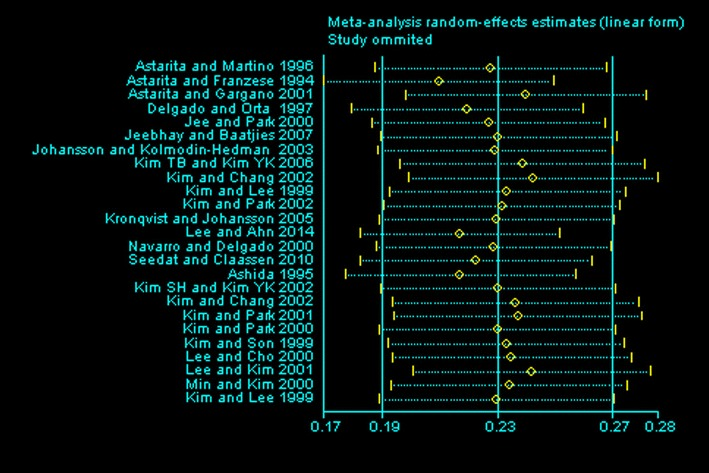



Paper: PMC6004667
Section: Results
Caption: Fig. 2 Forest plot of prevalence estimates of spider mite sensitization from included studies
Placeholder: PMC_FIG_1



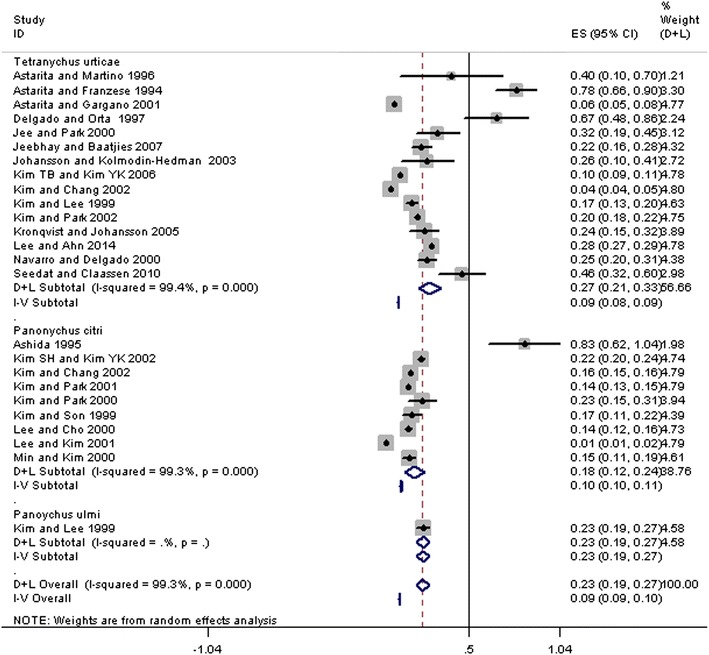



Paper: PMC6004667
Section: Results
Caption: Fig. 3 Funnel plot with pseudo 95% confidence limits
Placeholder: PMC_FIG_2



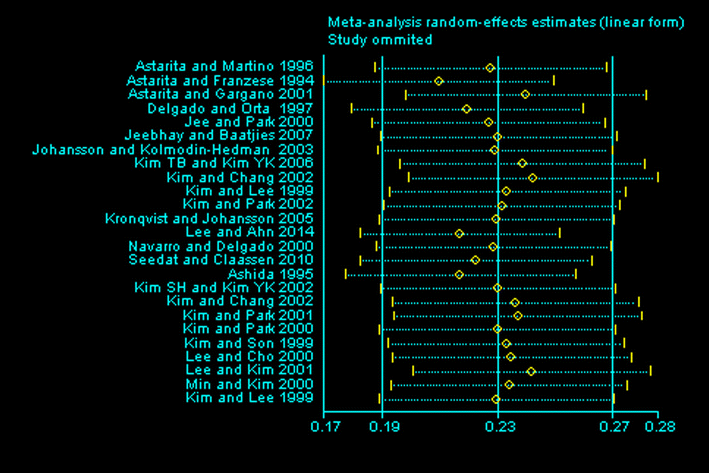



Paper: PMC6004667
Section: Results
Caption: Fig. 4 Meta-analysis random-effects estimates for all included studies
Placeholder: PMC_FIG_3



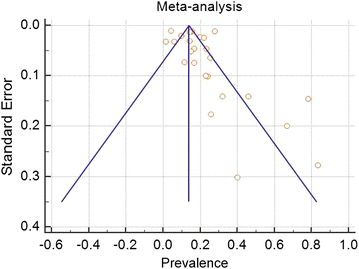



Paper: PMC6004667
Section: Results
Caption: Fig. 5 Forest plot of prevalence estimates of monosensitization of spider mite sensitization from included studies
Placeholder: PMC_FIG_4



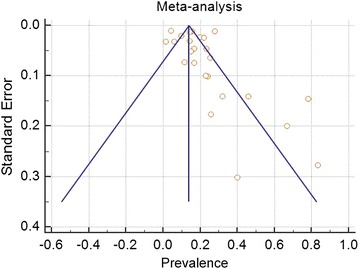



Paper: PMC6004667
Section: Characteristics of included studies
Caption: Fig. 1 Flow chart of screening and inclusion of studies for review and analysis
Placeholder: PMC_FIG_5



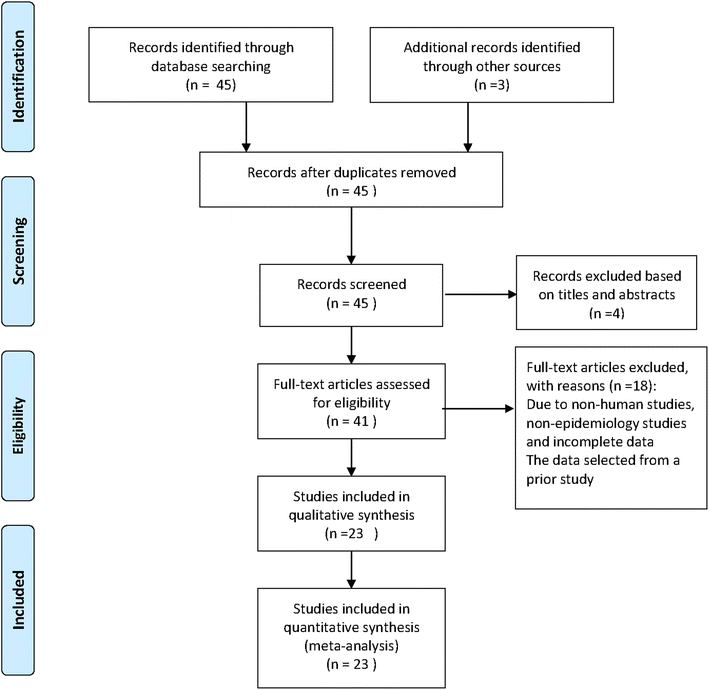



Paper: PMC6004667
Section: Prevalence of spider mite sensitization
Caption: Fig. 2 Forest plot of prevalence estimates of spider mite sensitization from included studies
Placeholder: PMC_FIG_6



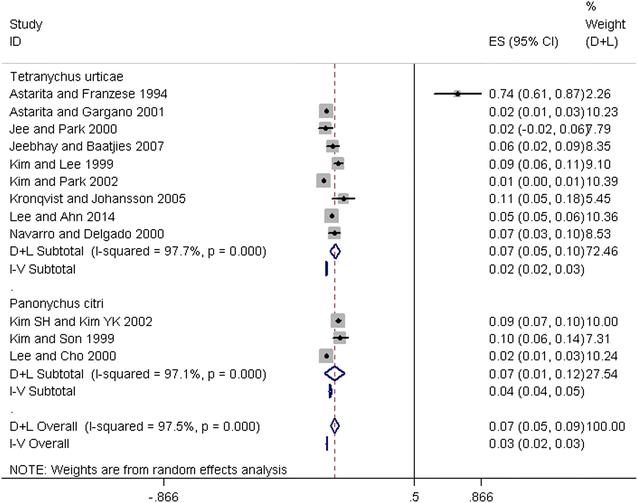



Paper: PMC6004667
Section: Publication bias, sensitivity, and meta-regression analysis
Caption: Fig. 3 Funnel plot with pseudo 95% confidence limits
Placeholder: PMC_FIG_7



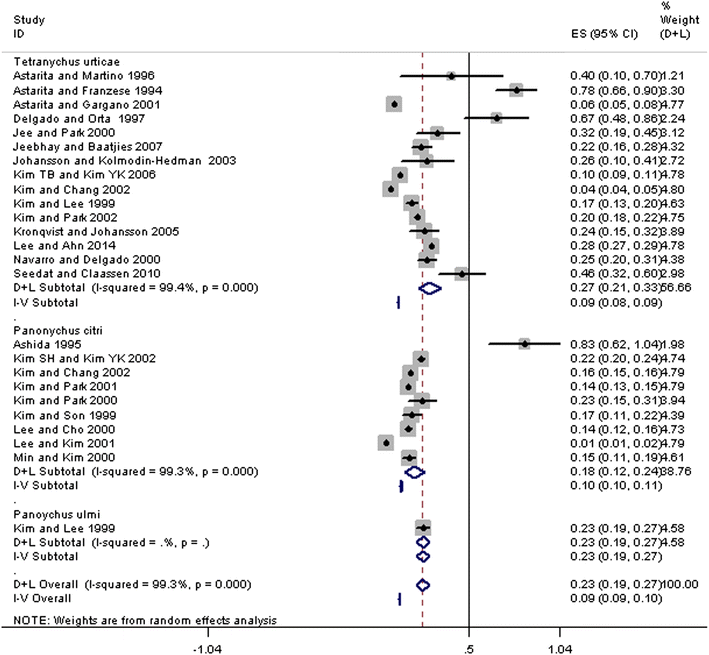



Paper: PMC6004667
Section: Publication bias, sensitivity, and meta-regression analysis
Caption: Fig. 4 Meta-analysis random-effects estimates for all included studies
Placeholder: PMC_FIG_8



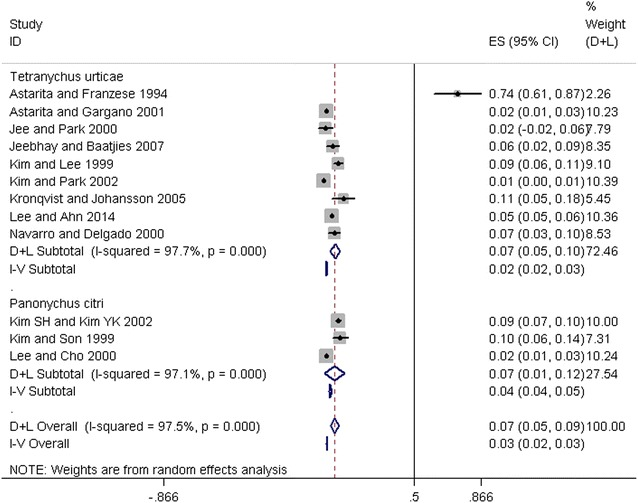



Paper: PMC6004667
Section: Monosensitization to spider mites
Caption: Fig. 5 Forest plot of prevalence estimates of monosensitization of spider mite sensitization from included studies
Placeholder: PMC_FIG_9



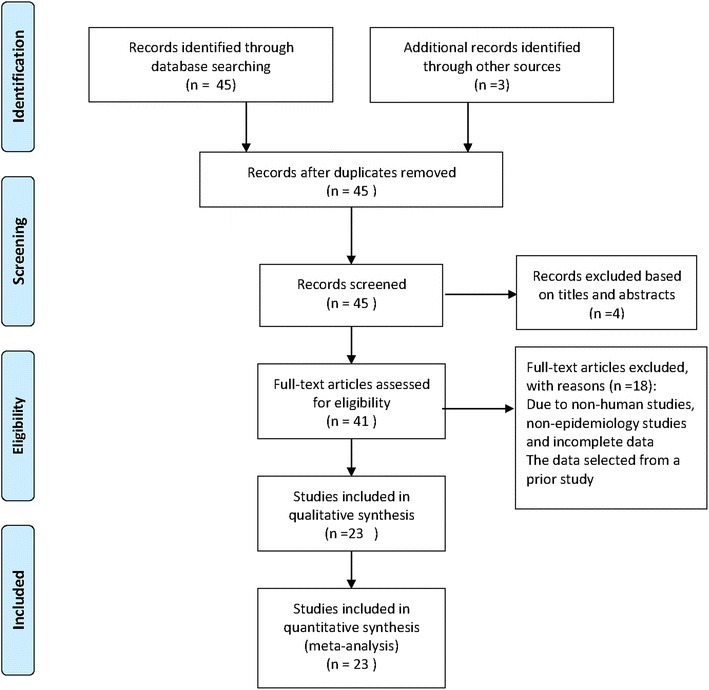



Paper: PMC6706894
Section: Results
Caption: Fig. 1 Preferred reporting items for systematic reviews and meta-analysis (PRISMA) flow diagram
Placeholder: PMC_FIG_0



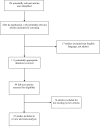



Paper: PMC10349543
Section: RESULTS
Caption: FIGURE 1 Flow diagram of the study selection process.
Placeholder: PMC_FIG_0



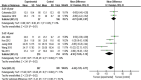



Paper: PMC10349543
Section: RESULTS
Caption: FIGURE 2 Forest plot showing the association between probiotics and Atopic dermatitis (AD).
Placeholder: PMC_FIG_1



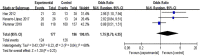



Paper: PMC10349543
Section: RESULTS
Caption: FIGURE 3 Forest plot showing the overall analysis of the SCORAD value.
Placeholder: PMC_FIG_2



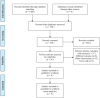



Paper: PMC10349543
Section: RESULTS
Caption: FIGURE 4 Forest plot showing subgroup analysis of SCORAD value by probiotic strain type.
Placeholder: PMC_FIG_3



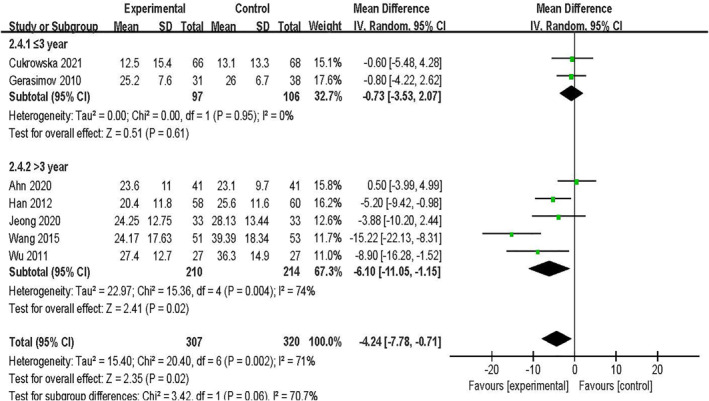

In [58]:
# Example 5: Display images from the export
if len(df_images) > 0:
    print(f"Total images in export: {len(df_images)}\n")
    print("Displaying 3 images from 20th position:\n")
    for i in range(min(0, len(df_images)), min(23, len(df_images))):
        show_image(i)
        print("\n" + "="*60 + "\n")


## Using Helper Functions

Use the helper functions below to inspect specific tables and images:

- `show_table(index)` — Display a specific table by index
- `show_image(index)` — Display a specific image by index
- `show_document(paper_id)` — Show metadata for a paper
- `show_document_sections(paper_id)` — Display all sections with tables and images

Examples:
```python
show_table(0)           # First table
show_image(0)           # First image
show_table(5)           # 6th table
show_image(3)           # 4th image
```
